In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Setting input parameters

In [ ]:
# Base dataset folder in Google Drive
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV created from your local preparation script
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder on Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_4_baseline_cnn_rgb_plus_depth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


Building RGB + depth paths

In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["depth_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "depth_raw.png")
)

# Check existence
df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())
df["depth_exists"] = df["depth_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:  ", (~df["rgb_exists"]).sum())
print("Missing depth images:", (~df["depth_exists"]).sum())

# Keep only rows where both exist
df = df[df["rgb_exists"] & df["depth_exists"]].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print(df.head())

Missing RGB images:   0
Missing depth images: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                            rgb_path  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  rgb_exists  depth_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...        True          True  
1  /content/drive/MyDrive/Spec

Creating Train / Validation / Test splits

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Setting model parameters

In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH = 480
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

Data loader

In [ ]:
def load_rgb_image(rgb_path):
    rgb = tf.io.read_file(rgb_path)
    rgb = tf.image.decode_png(rgb, channels=3)
    rgb = tf.image.resize(rgb, [IMG_HEIGHT, IMG_WIDTH])
    rgb = tf.cast(rgb, tf.float32)
    return rgb


def load_depth_image(depth_path):
    """
    Loads raw depth image as 1-channel.
    Assumes depth_raw.png is stored as uint16.
    Depth is normalized to [0,1] by dividing by 65535.
    """
    depth = tf.io.read_file(depth_path)

    # Most likely case for raw depth PNG
    depth = tf.image.decode_png(depth, channels=1, dtype=tf.uint16)

    # Resize depth map
    depth = tf.image.resize(depth, [IMG_HEIGHT, IMG_WIDTH], method="nearest")

    # Convert to float32
    depth = tf.cast(depth, tf.float32)

    # Normalize depth to [0,1]
    depth = depth / 65535.0

    return depth


def load_rgb_depth_and_label(rgb_path, depth_path, label):
    rgb = load_rgb_image(rgb_path)
    depth = load_depth_image(depth_path)
    label = tf.cast(label, tf.float32)

    return {
        "rgb_input": rgb,
        "depth_input": depth
    }, label

In [ ]:
def make_dataset(dataframe, batch_size=8, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    depth_paths = dataframe["depth_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, depth_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_depth_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Checking that both RGB and depth images has been created correctly

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:   ", batch_inputs["rgb_input"].shape)
    print("Depth batch shape: ", batch_inputs["depth_input"].shape)
    print("Labels batch shape:", batch_labels.shape)

RGB batch shape:    (8, 640, 480, 3)
Depth batch shape:  (8, 640, 480, 1)
Labels batch shape: (8,)


It should be 640x480x3 and 640x480x1

In [ ]:
from pathlib import Path
import os

def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)
df["depth_size"] = df["depth_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] == 0).sum())
print("Empty depth files:", (df["depth_size"] == 0).sum())

print("\nExample empty RGB files:")
print(df.loc[df["rgb_size"] == 0, ["dish_id", "rgb_path"]].head())

print("\nExample empty depth files:")
print(df.loc[df["depth_size"] == 0, ["dish_id", "depth_path"]].head())

Empty RGB files: 0
Empty depth files: 1

Example empty RGB files:
Empty DataFrame
Columns: [dish_id, rgb_path]
Index: []

Example empty depth files:
              dish_id                                         depth_path
2280  dish_1564159636  /content/drive/MyDrive/Speciale/dataset/nutrit...


In [ ]:
df["rgb_size"] = df["rgb_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)
df["depth_size"] = df["depth_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)

df = df[
    (df["rgb_exists"]) &
    (df["depth_exists"]) &
    (df["rgb_size"] > 0) &
    (df["depth_size"] > 0)
].copy()

print("Remaining samples after removing empty files:")
print(df["split"].value_counts())

Remaining samples after removing empty files:
split
train    2420
test      507
val       334
Name: count, dtype: int64


The two previous code blocks were created due the model throwing an error during training. The reason was due to one dish not having a proper depth_raw.png file, or it atleast had a value of 0 so that had to be removed before training of the network could proceed.

Model architecture

In [ ]:
# =========================================================
# RGB branch
# =========================================================
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")
x1 = layers.Rescaling(1.0 / 255)(rgb_input)

# RGB Block 1
x1 = layers.SeparableConv2D(32, 3, padding="same", use_bias=False)(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation("relu")(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

# RGB Block 2
x1 = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation("relu")(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

# RGB Block 3
x1 = layers.SeparableConv2D(128, 3, padding="same", use_bias=False)(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation("relu")(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

# RGB Block 4
x1 = layers.SeparableConv2D(256, 3, padding="same", use_bias=False)(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation("relu")(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

# RGB Block 5
x1 = layers.SeparableConv2D(512, 3, padding="same", use_bias=False)(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation("relu")(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

x1 = layers.GlobalAveragePooling2D()(x1)


# =========================================================
# Depth branch
# =========================================================
depth_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="depth_input")
x2 = depth_input

# Depth Block 1
x2 = layers.SeparableConv2D(16, 3, padding="same", use_bias=False)(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Activation("relu")(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)

# Depth Block 2
x2 = layers.SeparableConv2D(32, 3, padding="same", use_bias=False)(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Activation("relu")(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)

# Depth Block 3
x2 = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Activation("relu")(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)

# Depth Block 4
x2 = layers.SeparableConv2D(128, 3, padding="same", use_bias=False)(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Activation("relu")(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)

x2 = layers.GlobalAveragePooling2D()(x2)


# =========================================================
# Fusion head
# =========================================================
x = layers.Concatenate()([x1, x2])

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="linear")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input, "depth_input": depth_input},
    outputs=outputs,
    name="baseline_cnn_rgb_depth_fusion_carb_regression"
)

model.summary()

Model: "baseline_cnn_rgb_depth_fusion_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 640, 480,  │          0 │ rgb_input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 640, 480,  │        123 │ rescaling[0][0]   │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 640, 480,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 640, 480,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 320, 240,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_input         │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 320, 240,  │      2,336 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_5  │ (None, 640, 480,  │         25 │ depth_input[0][0] │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 240,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 640, 480,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 320, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 640, 480,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 160, 120,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 320, 240,  │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 160, 120,  │      8,768 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 320, 240,  │        656 │ max_pooling2d_5[

 Total params: 375,845 (1.43 MB)

 Trainable params: 373,381 (1.42 MB)

 Non-trainable params: 2,464 (9.62 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

Training model

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=200,
    callbacks=callbacks
)

Epoch 1/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 780.6355 - mae: 12.4330 - mse: 780.6355
Epoch 1: val_loss improved from None to 541.27734, saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb_plus_depth/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb_plus_depth/best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 2037s 7s/step - loss: 499.0108 - mae: 11.5138 - mse: 499.0108 - val_loss: 541.2773 - val_mae: 17.7290 - val_mse: 541.2773 - learning_rate: 0.0010
Epoch 2/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 245.2240 - mae: 10.5606 - mse: 245.2240
Epoch 2: val_loss improved from 541.27734 to 172.21735, saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb_plus_depth/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb_plus_depth/best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 79s 260ms/step - loss: 482.5309 - mae: 10.9074 -

Visualizing training and validation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Loss
    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # MAE
    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)
    else:
        axes[1].set_visible(False)

    # MSE
    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

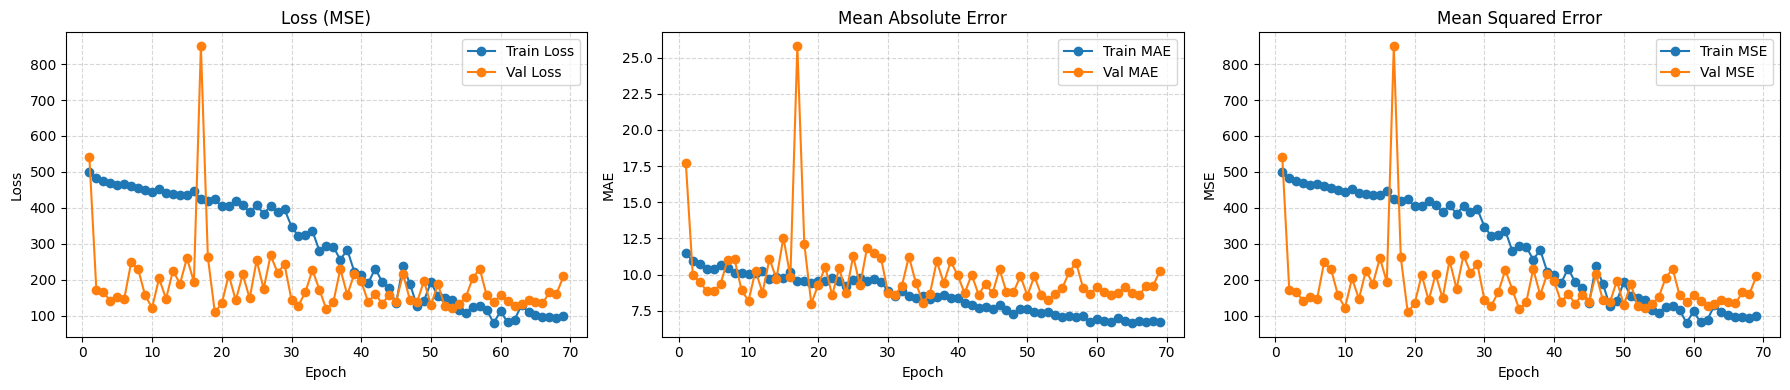

Best val_loss: 108.9076 at epoch 19
Val MAE at best epoch: 7.9934
Val MSE at best epoch: 108.9076


In [ ]:
plot_metrics(history)

Evaluating on test set

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

Loading model back in

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"))

In [ ]:
loaded_model_test_results = loaded_model.evaluate(test_dataset, return_dict=True)
print(loaded_model_test_results)

64/64 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - loss: 127.2228 - mae: 8.3041 - mse: 127.2228
{'loss': 127.22281646728516, 'mae': 8.304141998291016, 'mse': 127.22281646728516}
